In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [33]:
df=pd.read_csv("../Datasets/placement.csv")

In [34]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


C:\Users\anush\AppData\Local\Temp\ipykernel_23048\1747465797.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\anush\AppData\Local\Temp\ipykernel_23048\1747465797.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


Text(0.5, 1.0, 'placement_exam_marks')

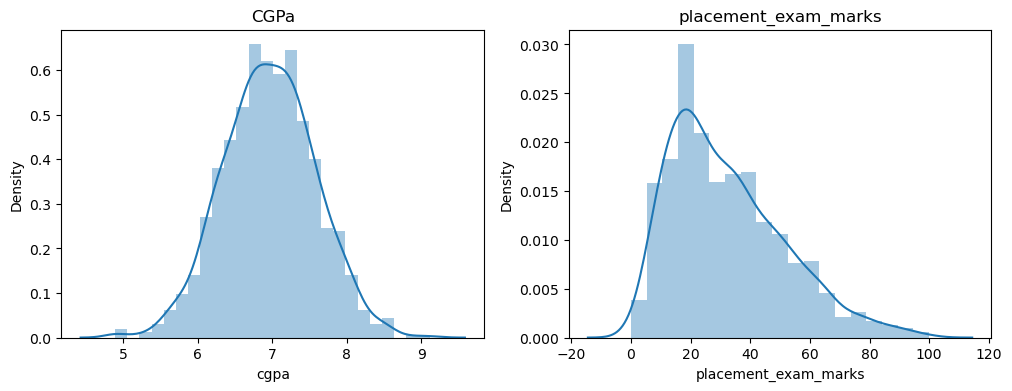

In [35]:
plt.figure(figsize=(12,4))
plt.subplot(121)
sns.distplot(df['cgpa'])
plt.title("CGPa")

plt.subplot(122)
sns.distplot(df['placement_exam_marks'])
plt.title("placement_exam_marks")

In [36]:
df['placement_exam_marks'].skew()

0.8356419499466834

In [37]:
print("Mean of the Cgpa is ",df['cgpa'].mean())
print("std of the Cgpa is ",df['cgpa'].std())
print("Min value in  the Cgpa is ",df['cgpa'].min())
print("Max value in  the Cgpa is ",df['cgpa'].max())

Mean of the Cgpa is  6.96124
std of the Cgpa is  0.6158978751323894
Min value in  the Cgpa is  4.89
Max value in  the Cgpa is  9.12


In [38]:
print("Highest Boundary ",df['cgpa'].mean()+3*df['cgpa'].std())
print("Lowest Boundary ",df['cgpa'].mean()-3*df['cgpa'].std())

Highest Boundary  8.808933625397168
Lowest Boundary  5.113546374602832


In [39]:
df[(df['cgpa']>8.80) | (df['cgpa']<5.10)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


#### Trimming 

In [40]:
new_df=df[(df['cgpa']<8.80) & (df['cgpa']>5.10)]
new_df.shape

(995, 3)

In [41]:
## using z-score 
df['cgpa_score']=(df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()

In [42]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [43]:
df[(df['cgpa_score'])>3]

,cgpa,placement_exam_marks,placed,cgpa_score
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [44]:
df[(df['cgpa_score'])<-3]

,cgpa,placement_exam_marks,placed,cgpa_score
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [45]:
df[(df['cgpa_score']>3) | (df['cgpa_score']<-3)]

,cgpa,placement_exam_marks,placed,cgpa_score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [46]:
new_df1=df[(df['cgpa_score']<3) & (df['cgpa_score']>-3)]
new_df1.shape

(995, 4)

#### Capping

In [47]:
upper_limit=df['cgpa'].mean()+3*df['cgpa'].std()
lower_limit=df['cgpa'].mean()-3*df['cgpa'].std()

In [48]:
print(upper_limit,lower_limit)

8.808933625397168 5.113546374602832


In [49]:
df['cgpa_new']=np.where(df['cgpa']>upper_limit,
                    upper_limit,
                    np.where(
                        df['cgpa']<lower_limit,
                        lower_limit,
                        df['cgpa']
                    ))

In [50]:
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_score,cgpa_new
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000
mean,6.961240,32.225000,0.489000,-1.474376e-16,6.961499
std,0.615898,19.130822,0.500129,1.000000e+00,0.612688
min,4.890000,0.000000,0.000000,-3.362960e+00,5.113546
25%,6.550000,17.000000,0.000000,-6.677081e-01,6.550000
50%,6.960000,28.000000,0.000000,-2.013321e-03,6.960000
75%,7.370000,44.000000,1.000000,6.636815e-01,7.370000
max,9.120000,100.000000,1.000000,3.505062e+00,8.808934


C:\Users\anush\AppData\Local\Temp\ipykernel_23048\1458446376.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\anush\AppData\Local\Temp\ipykernel_23048\1458446376.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa_new'])


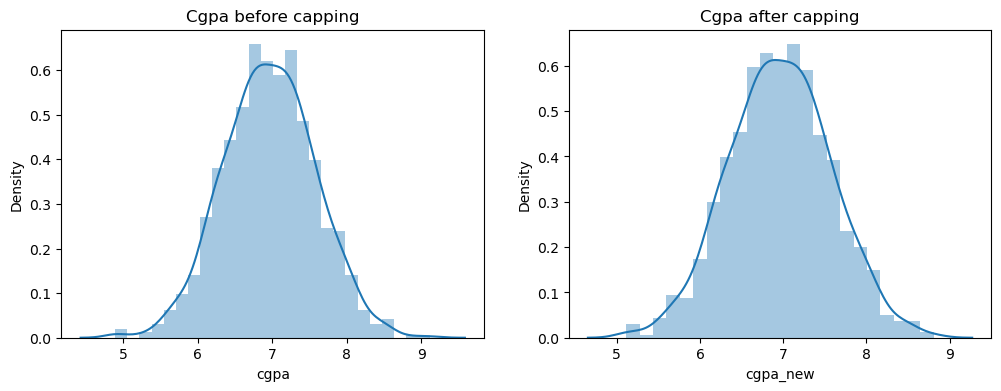

In [52]:
plt.figure(figsize=(12,4))
plt.subplot(121)
sns.distplot(df['cgpa'])
plt.title('Cgpa before capping')

plt.subplot(122)
sns.distplot(df['cgpa_new'])
plt.title('Cgpa after capping')
plt.show()

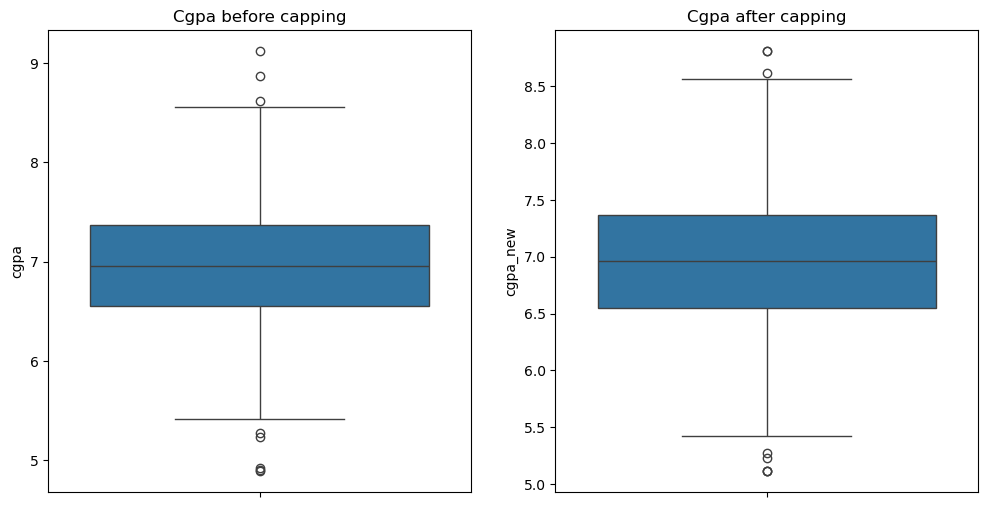

In [56]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.boxplot(df['cgpa'])
plt.title('Cgpa before capping')

plt.subplot(122)
sns.boxplot(df['cgpa_new'])
plt.title('Cgpa after capping')
plt.show()